In [11]:
import pandas as pd 
import numpy as np

In [14]:

from scipy.special import logsumexp

# -----------------------------
# File paths
# -----------------------------
train_logit_path_cifar = r'cifar10_train_logit_vit.csv'
test_id_logit_path_cifar = r'cifar10_test_logit_vit.csv'
test_ood_logit_path_cifar = r'cifar100_test_logit_vit.csv'

train_logit_path_mnist = r'mnist_train_id_0_5_logit_cnn.csv'
test_id_logit_path_mnist = r'mnist_test_id_0_5_logit_cnn.csv'
test_ood_logit_path_mnist = r'mnist_test_ood_6_9_logit_cnn.csv'

train_logit_path_svhn = r'svhn_train_id_logit_wrn.csv'
test_id_logit_path_svhn = r'svhn_test_id_logit_wrn.csv'
test_ood_logit_path_svhn = r'svhn_test_ood_logit_wrn.csv'

train_logit_path_cifar_first6 = r'cifar10_train_id_first6_logit_vit.csv'
test_id_logit_path_cifar_first6 = r'cifar10_test_id_first6_logit_vit.csv'
test_ood_logit_path_cifar_first6 = r'cifar10_test_ood_last4_logit_vit.csv'


# -----------------------------
# Helpers
# -----------------------------
def load_logit_csv(path):
    """
    Load a CSV where:
      - column 0 = true class
      - remaining columns = logits

    header=None is important because your files appear to have no real header row.
    """
    df = pd.read_csv(path, header=None)
    return df


def compute_mls_and_energy(df, dataset_name=None, split_name=None, is_ood=False, label_offset=0):
    """
    Given a dataframe with:
      col 0 = true label
      col 1... = logits

    Returns a dataframe with:
      true_label, adjusted_label, pred_label, mls, energy, is_ood, dataset, split
    """
    labels = df.iloc[:, 0].astype(int).to_numpy()
    logits = df.iloc[:, 1:].to_numpy(dtype=float)

    # MLS = max logit
    mls = np.max(logits, axis=1)

    # Energy score = -logsumexp(logits)
    energy = -logsumexp(logits, axis=1)

    # Predicted class index among the provided logits
    pred_label = np.argmax(logits, axis=1)

    out = pd.DataFrame({
        "true_label": labels,
        "adjusted_label": labels + label_offset,
        "pred_label": pred_label,
        "mls": mls,
        "energy": energy,
        "is_ood": int(is_ood),
        "dataset": dataset_name,
        "split": split_name,
    })

    return out


def build_combined_test(
    test_id_path,
    test_ood_path,
    dataset_name,
    ood_label_offset=0
):
    """
    Build one combined test set from ID + OOD.
    For CIFAR OOD, you asked to add +4 to labels.
    """
    test_id_df = load_logit_csv(test_id_path)
    test_ood_df = load_logit_csv(test_ood_path)

    id_scores = compute_mls_and_energy(
        test_id_df,
        dataset_name=dataset_name,
        split_name="test_id",
        is_ood=False,
        label_offset=0
    )

    ood_scores = compute_mls_and_energy(
        test_ood_df,
        dataset_name=dataset_name,
        split_name="test_ood",
        is_ood=True,
        label_offset=ood_label_offset
    )

    combined_test = pd.concat([id_scores, ood_scores], ignore_index=True)
    return combined_test, id_scores, ood_scores


def build_train_scores(train_path, dataset_name):
    train_df = load_logit_csv(train_path)
    train_scores = compute_mls_and_energy(
        train_df,
        dataset_name=dataset_name,
        split_name="train",
        is_ood=False,
        label_offset=0
    )
    return train_scores


# -----------------------------
# CIFAR
# -----------------------------
train_scores_cifar = build_train_scores(train_logit_path_cifar, "cifar")

combined_test_cifar, test_id_scores_cifar, test_ood_scores_cifar = build_combined_test(
    test_id_path=test_id_logit_path_cifar,
    test_ood_path=test_ood_logit_path_cifar,
    dataset_name="cifar",
    ood_label_offset=4   # per your request
)

print("CIFAR combined test shape:", combined_test_cifar.shape)
print(combined_test_cifar.head())
##first 6
train_scores_cifar_first6 = build_train_scores(train_logit_path_cifar_first6, "cifar")

combined_test_cifar_first6, test_id_scores_cifar_first6, test_ood_scores_cifar_first6 = build_combined_test(
    test_id_path=test_id_logit_path_cifar_first6,
    test_ood_path=test_ood_logit_path_cifar_first6,
    dataset_name="cifar_first6",
    ood_label_offset=0   # per your request
)

print("CIFAR combined test shape:", combined_test_cifar_first6.shape)
print(combined_test_cifar_first6.head())



# -----------------------------
# MNIST
# -----------------------------
train_scores_mnist = build_train_scores(train_logit_path_mnist, "mnist")

combined_test_mnist, test_id_scores_mnist, test_ood_scores_mnist = build_combined_test(
    test_id_path=test_id_logit_path_mnist,
    test_ood_path=test_ood_logit_path_mnist,
    dataset_name="mnist",
    ood_label_offset=0   # no offset requested
)

print("MNIST combined test shape:", combined_test_mnist.shape)
print(combined_test_mnist.head())


# -----------------------------
# SVHN
# -----------------------------
train_scores_svhn = build_train_scores(train_logit_path_svhn, "svhn")

combined_test_svhn, test_id_scores_svhn, test_ood_scores_svhn = build_combined_test(
    test_id_path=test_id_logit_path_svhn,
    test_ood_path=test_ood_logit_path_svhn,
    dataset_name="svhn",
    ood_label_offset=0   # no offset requested
)

print("SVHN combined test shape:", combined_test_svhn.shape)
print(combined_test_svhn.head())


# -----------------------------
# Optional: save results
# -----------------------------
train_scores_cifar.to_csv("cifar_train_scores.csv", index=False)
combined_test_cifar.to_csv("cifar_combined_test_scores.csv", index=False)

train_scores_cifar_first6.to_csv("cifar_train_scores_first6.csv", index=False)
combined_test_cifar_first6.to_csv("cifar_combined_test_scores_first6.csv", index=False)

train_scores_mnist.to_csv("mnist_train_scores.csv", index=False)
combined_test_mnist.to_csv("mnist_combined_test_scores.csv", index=False)

train_scores_svhn.to_csv("svhn_train_scores.csv", index=False)
combined_test_svhn.to_csv("svhn_combined_test_scores.csv", index=False)

CIFAR combined test shape: (14000, 8)
   true_label  adjusted_label  pred_label       mls    energy  is_ood dataset  \
0           3               3           3  4.819623 -4.824547       0   cifar   
1           0               0           0  4.579016 -4.585658       0   cifar   
2           1               1           1  5.556546 -5.559093       0   cifar   
3           3               3           3  4.862905 -4.867590       0   cifar   
4           1               1           1  5.494577 -5.497497       0   cifar   

     split  
0  test_id  
1  test_id  
2  test_id  
3  test_id  
4  test_id  
CIFAR combined test shape: (10000, 8)
   true_label  adjusted_label  pred_label       mls    energy  is_ood  \
0           3               3           3  5.005251 -5.017111       0   
1           0               0           0  5.358467 -5.368069       0   
2           1               1           1  6.307973 -6.311699       0   
3           3               3           3  4.968855 -4.980833      

In [15]:

import csv


# =========================================================
# File paths
# =========================================================
train_logit_path_cifar = r'cifar10_train_logit_vit.csv'
test_id_logit_path_cifar = r'cifar10_test_logit_vit.csv'
test_ood_logit_path_cifar = r'cifar100_test_logit_vit.csv'

train_logit_path_mnist = r'mnist_train_id_0_5_logit_cnn.csv'
test_id_logit_path_mnist = r'mnist_test_id_0_5_logit_cnn.csv'
test_ood_logit_path_mnist = r'mnist_test_ood_6_9_logit_cnn.csv'

train_logit_path_svhn = r'svhn_train_id_logit_wrn.csv'
test_id_logit_path_svhn = r'svhn_test_id_logit_wrn.csv'
test_ood_logit_path_svhn = r'svhn_test_ood_logit_wrn.csv'

train_logit_path_cifar_first6 = r'cifar10_train_id_first6_logit_vit.csv'
test_id_logit_path_cifar_first6 = r'cifar10_test_id_first6_logit_vit.csv'
test_ood_logit_path_cifar_first6 = r'cifar10_test_ood_last4_logit_vit.csv'
# =========================================================
# Helpers
# =========================================================
def load_logit_csv(path):
    """
    CSV format:
      col 0 = true label
      col 1... = logits
    """
    return pd.read_csv(path, header=None)


def get_labels_and_logits(df):
    true_labels = df.iloc[:, 0].astype(int).to_numpy()
    logits = df.iloc[:, 1:].to_numpy(dtype=float)
    return true_labels, logits


def compute_scores_from_logits(logits):
    """
    Returns:
      pred_class : argmax logit
      mls        : max logit
      energy     : -logsumexp(logits)
    """
    pred_class = np.argmax(logits, axis=1)
    mls = np.max(logits, axis=1)
    energy = -logsumexp(logits, axis=1)
    return pred_class, mls, energy


def build_combined_test_df(test_id_path, test_ood_path, dataset_name, ood_label_offset=0):
    """
    Combine ID and OOD test sets.
    OOD labels can be offset so they do not overlap with ID labels.
    """
    # ID
    df_id = load_logit_csv(test_id_path)
    id_true, id_logits = get_labels_and_logits(df_id)
    id_pred, id_mls, id_energy = compute_scores_from_logits(id_logits)

    id_out = pd.DataFrame({
        "true_label_raw": id_true,
        "true_label": id_true,  # ID labels unchanged
        "pred_id_class": id_pred,
        "mls": id_mls,
        "energy": id_energy,
        "is_ood": 0
    })

    # OOD
    df_ood = load_logit_csv(test_ood_path)
    ood_true, ood_logits = get_labels_and_logits(df_ood)
    ood_pred, ood_mls, ood_energy = compute_scores_from_logits(ood_logits)

    ood_out = pd.DataFrame({
        "true_label_raw": ood_true,
        "true_label": ood_true + ood_label_offset,  # offset if needed
        "pred_id_class": ood_pred,
        "mls": ood_mls,
        "energy": ood_energy,
        "is_ood": 1
    })

    combined = pd.concat([id_out, ood_out], ignore_index=True)
    combined["dataset"] = dataset_name
    return combined


def threshold_from_fpr95_id(scores_id, score_type="mls"):
    """
    FPR95-style threshold using the ID distribution only:
      - MLS: higher = more ID-like
             choose threshold so 95% of ID samples are ABOVE threshold
             => threshold = 5th percentile of ID MLS
      - Energy: lower = more ID-like
                choose threshold so 95% of ID samples are BELOW threshold
                => threshold = 95th percentile of ID energy
    """
    if score_type == "mls":
        return np.percentile(scores_id, 5.0)
    elif score_type == "energy":
        return np.percentile(scores_id, 95.0)
    else:
        raise ValueError("score_type must be 'mls' or 'energy'")


def apply_reject_rule(df, threshold, id_class_count, score_type="mls"):
    """
    Predict final class with reject option.
    Reject class index = id_class_count

    For ID samples:
      predicted class = argmax(logit) if score passes threshold
      otherwise reject

    For OOD samples:
      same logic; if rejected, final pred = reject_class
      if not rejected, final pred = argmax(logit)

    Returns a copy with:
      final_pred
    """
    reject_class = id_class_count
    out = df.copy()

    if score_type == "mls":
        # higher MLS = more ID-like
        out["final_pred"] = np.where(
            out["mls"] >= threshold,
            out["pred_id_class"],
            reject_class
        )
    elif score_type == "energy":
        # lower energy = more ID-like
        out["final_pred"] = np.where(
            out["energy"] <= threshold,
            out["pred_id_class"],
            reject_class
        )
    else:
        raise ValueError("score_type must be 'mls' or 'energy'")

    out["final_pred"] = out["final_pred"].astype(int)
    return out


def compute_classwise_fmeasure(df_pred, id_class_count):
    """
    Same spirit as your script.

    Convention:
      - true OOD samples have true_label >= id_class_count
      - predicted reject class = id_class_count

    For OOD true sample:
      correct iff final_pred == reject_class
    For ID true sample:
      correct iff final_pred == true_label

    Returns:
      classList, truePos, falsePos, falseNeg, fmeasure
    """
    reject_class = id_class_count

    # include all true labels + reject class
    classList = sorted(df_pred["true_label"].unique().tolist())
    if reject_class not in classList:
        classList.append(reject_class)
        classList = sorted(classList)

    truePos = {c: 0.0 for c in classList}
    falsePos = {c: 0.0 for c in classList}
    falseNeg = {c: 0.0 for c in classList}

    for _, row in df_pred.iterrows():
        trueClass = int(row["true_label"])
        predClass = int(row["final_pred"])

        if trueClass > (id_class_count - 1):  # OOD true class
            if predClass == reject_class:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                if predClass not in falsePos:
                    falsePos[predClass] = 0.0
                falsePos[predClass] += 1
        else:  # ID true class
            if predClass == trueClass:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                if predClass not in falsePos:
                    falsePos[predClass] = 0.0
                falsePos[predClass] += 1

    precision = {c: 0.0 for c in classList}
    recall = {c: 0.0 for c in classList}
    fmeasure = {c: 0.0 for c in classList}

    for c in classList:
        tp = truePos[c]
        fp = falsePos[c]
        fn = falseNeg[c]

        if tp + fp > 0:
            precision[c] = tp / (tp + fp)
        else:
            precision[c] = 0.0

        if tp + fn > 0:
            recall[c] = tp / (tp + fn)
        else:
            recall[c] = 0.0

        denom = tp + 0.5 * (fp + fn)
        if denom > 0:
            fmeasure[c] = tp / denom
        else:
            fmeasure[c] = 0.0

    return classList, truePos, falsePos, falseNeg, precision, recall, fmeasure


def save_fmeasure_csv(filename, classList, fmeasure):
    with open(filename, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        rowZero = [" "] + classList
        writer.writerow(rowZero)

        rowTwo = ["fmeasure"]
        for c in classList:
            rowTwo.append(fmeasure[c])
        writer.writerow(rowTwo)


def evaluate_one_dataset(
    dataset_name,
    test_id_path,
    test_ood_path,
    ood_label_offset=0
):
    """
    Full pipeline for one dataset:
      - build combined test set
      - get ID class count from logits
      - threshold MLS and Energy using ID test scores
      - apply reject rule
      - compute classwise F-measure
      - save CSVs
    """
    combined = build_combined_test_df(
        test_id_path=test_id_path,
        test_ood_path=test_ood_path,
        dataset_name=dataset_name,
        ood_label_offset=ood_label_offset
    )

    # infer number of ID classes from max predicted class + 1 among ID samples
    # safer way: load ID file and count logits directly
    df_id_raw = load_logit_csv(test_id_path)
    id_class_count = df_id_raw.shape[1] - 1   # first col is label, rest are logits
    reject_class = id_class_count

    # threshold from ID subset only
    id_only = combined[combined["is_ood"] == 0].copy()

    mls_threshold = threshold_from_fpr95_id(id_only["mls"].to_numpy(), score_type="mls")
    energy_threshold = threshold_from_fpr95_id(id_only["energy"].to_numpy(), score_type="energy")

    print(f"\n=== {dataset_name.upper()} ===")
    print("ID class count:", id_class_count)
    print("Reject class index:", reject_class)
    print("MLS threshold (95% ID kept):", mls_threshold)
    print("Energy threshold (95% ID kept):", energy_threshold)

    # Apply reject rule
    combined_mls = apply_reject_rule(combined, mls_threshold, id_class_count, score_type="mls")
    combined_energy = apply_reject_rule(combined, energy_threshold, id_class_count, score_type="energy")

    # Save full prediction files
    combined_mls.to_csv(f"{dataset_name}_combined_test_mls_scores.csv", index=False)
    combined_energy.to_csv(f"{dataset_name}_combined_test_energy_scores.csv", index=False)

    # Compute F-measure
    classList_mls, tp_mls, fp_mls, fn_mls, prec_mls, rec_mls, f_mls = compute_classwise_fmeasure(
        combined_mls, id_class_count
    )
    classList_energy, tp_energy, fp_energy, fn_energy, prec_energy, rec_energy, f_energy = compute_classwise_fmeasure(
        combined_energy, id_class_count
    )

    # Save classwise fmeasure
    save_fmeasure_csv(f"top1fmeasure_{dataset_name}_mls.csv", classList_mls, f_mls)
    save_fmeasure_csv(f"top1fmeasure_{dataset_name}_energy.csv", classList_energy, f_energy)

    # Also print them
    print("\nMLS class-wise F-measure")
    for c in classList_mls:
        print(f"class {c}: {f_mls[c]:.6f}")

    print("\nEnergy class-wise F-measure")
    for c in classList_energy:
        print(f"class {c}: {f_energy[c]:.6f}")

    return {
        "combined": combined,
        "combined_mls": combined_mls,
        "combined_energy": combined_energy,
        "mls_threshold": mls_threshold,
        "energy_threshold": energy_threshold,
        "f_mls": f_mls,
        "f_energy": f_energy,
        "classList_mls": classList_mls,
        "classList_energy": classList_energy,
    }


# =========================================================
# Run all datasets
# =========================================================

# CIFAR:
# You said cifar_ood is from cifar100 and labels start from 0,
# so add 4 to make them different from the CIFAR ID labels.
results_cifar = evaluate_one_dataset(
    dataset_name="cifar",
    test_id_path=test_id_logit_path_cifar,
    test_ood_path=test_ood_logit_path_cifar,
    ood_label_offset=4
)

results_cifar_first6 = evaluate_one_dataset(
    dataset_name="cifar_first6",
    test_id_path=test_id_logit_path_cifar_first6,
    test_ood_path=test_ood_logit_path_cifar_first6,
    ood_label_offset=0
)

results_mnist = evaluate_one_dataset(
    dataset_name="mnist",
    test_id_path=test_id_logit_path_mnist,
    test_ood_path=test_ood_logit_path_mnist,
    ood_label_offset=0
)

results_svhn = evaluate_one_dataset(
    dataset_name="svhn",
    test_id_path=test_id_logit_path_svhn,
    test_ood_path=test_ood_logit_path_svhn,
    ood_label_offset=0
)


=== CIFAR ===
ID class count: 4
Reject class index: 4
MLS threshold (95% ID kept): 4.315387272834778
Energy threshold (95% ID kept): -4.3273964316502305

MLS class-wise F-measure
class 0: 0.904412
class 1: 0.895023
class 2: 0.880516
class 3: 0.710387
class 4: 0.500000
class 5: 1.000000
class 6: 0.974359
class 7: 0.895028
class 8: 0.907104
class 9: 0.994975
class 10: 0.963731
class 11: 0.963731
class 12: 0.994975
class 13: 1.000000
class 14: 0.994975
class 15: 0.984772
class 16: 0.888889
class 17: 0.529412
class 18: 0.974359
class 19: 0.907104
class 20: 1.000000
class 21: 0.994975
class 22: 0.979592
class 23: 0.952880
class 24: 1.000000
class 25: 0.994975
class 26: 1.000000
class 27: 0.974359
class 28: 0.989899
class 29: 0.989899
class 30: 0.969072
class 31: 0.947368
class 32: 0.994975
class 33: 0.918919
class 34: 0.901099
class 35: 0.958333
class 36: 0.958333
class 37: 0.989899
class 38: 0.561151
class 39: 0.994975
class 40: 0.387097
class 41: 0.974359
class 42: 0.882682
class 43: 0.9

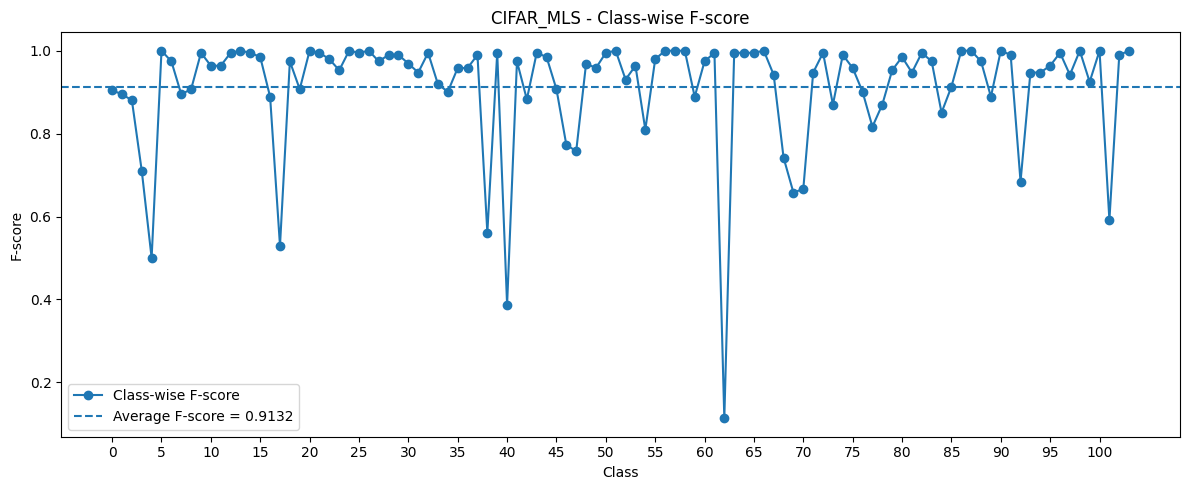

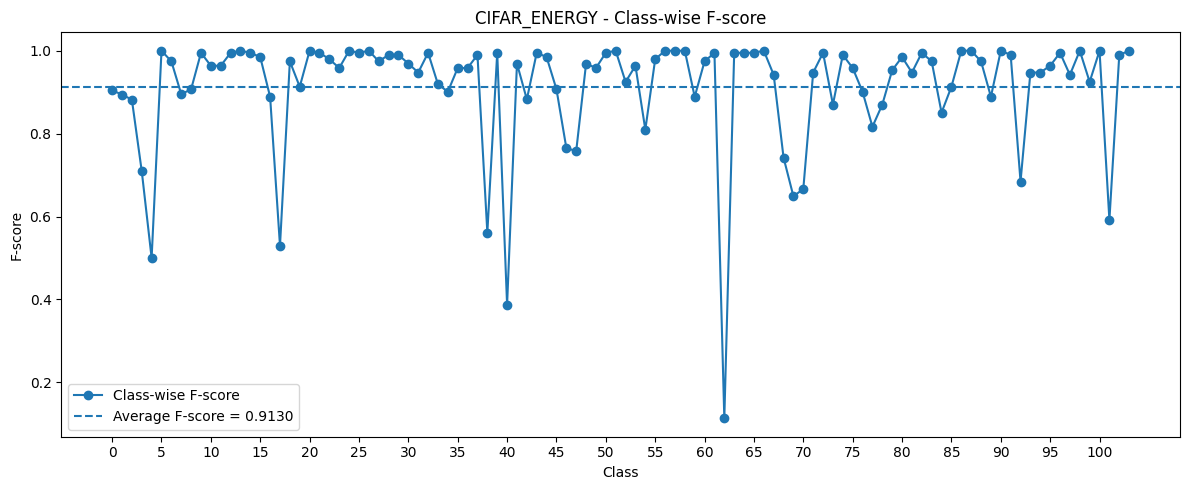

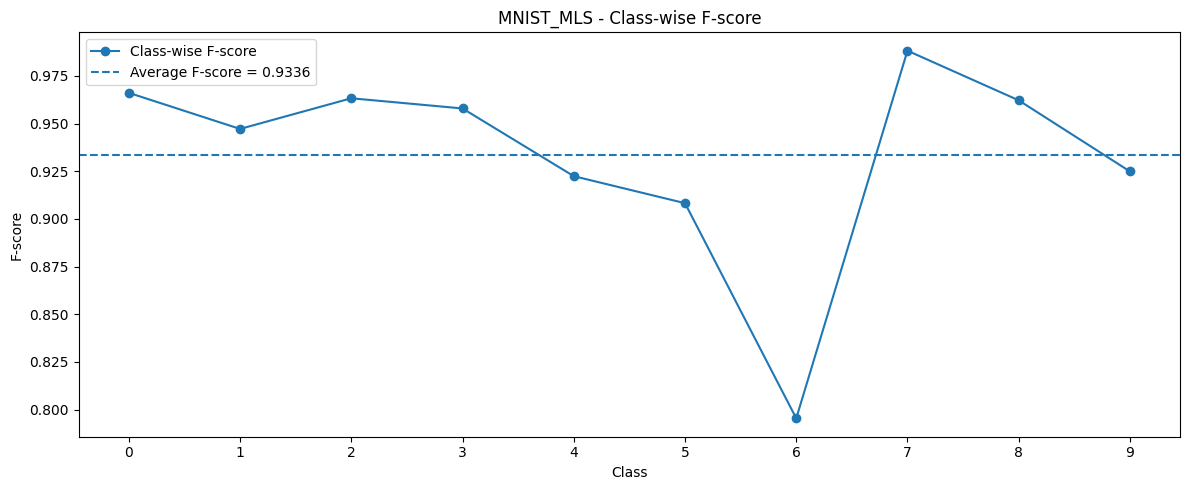

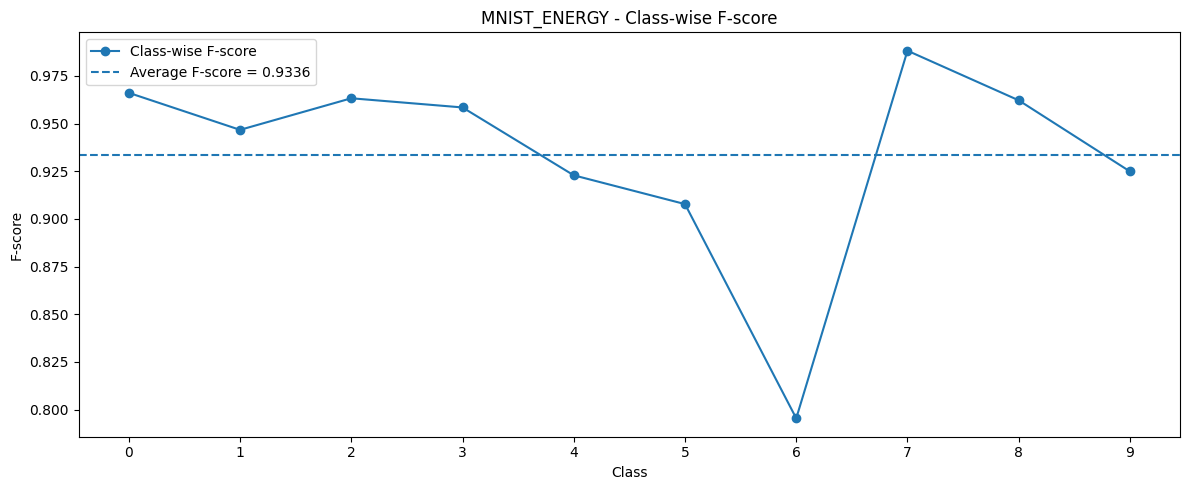

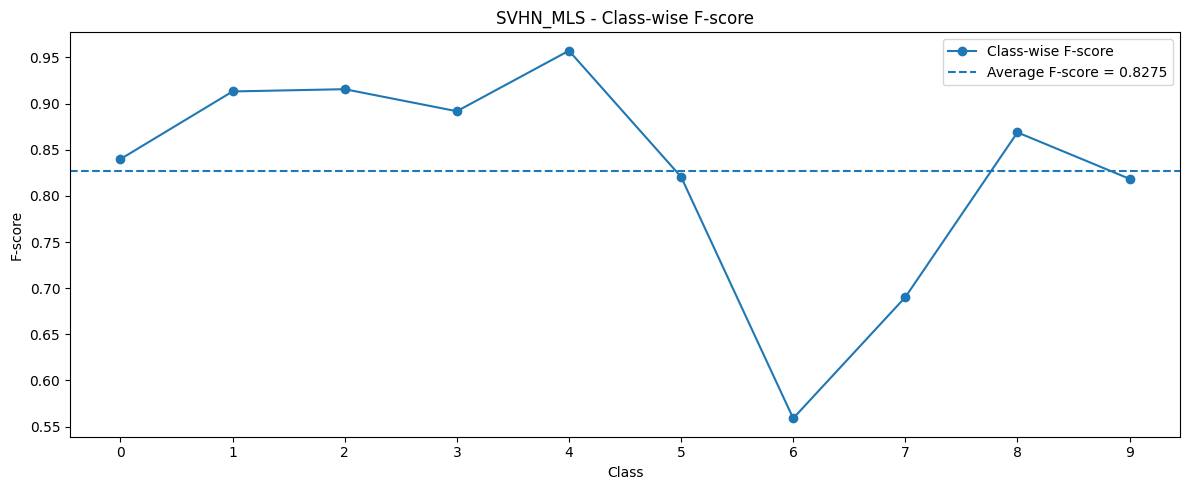

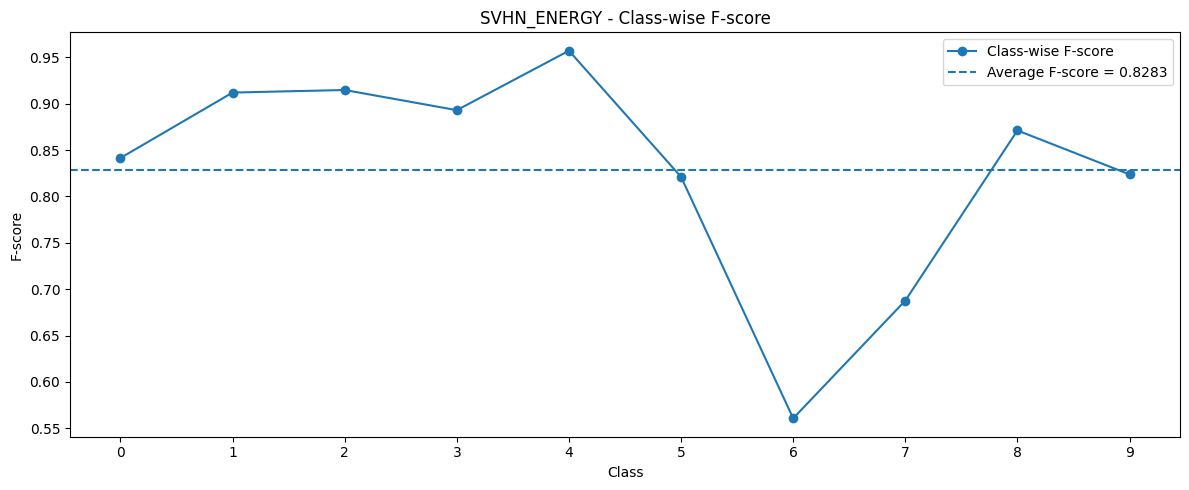

In [16]:
import matplotlib.pyplot as plt
import numpy as np


def plot_avg_fscore_by_class(fmeasure_dict, dataset_name, save_path=None):
    """
    fmeasure_dict: dict {class_id: f_score}
    dataset_name: string (e.g., 'cifar')
    """

    # Sort classes
    classes = sorted(fmeasure_dict.keys())
    f_scores = np.array([fmeasure_dict[c] for c in classes])

    # Average F-score across all classes
    avg_f = np.mean(f_scores)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(classes, f_scores, marker='o', linestyle='-', label='Class-wise F-score')

    # Horizontal average line
    plt.axhline(y=avg_f, linestyle='--', label=f'Average F-score = {avg_f:.4f}')

    # Labels and title
    plt.xlabel('Class')
    plt.ylabel('F-score')
    plt.title(f'{dataset_name.upper()} - Class-wise F-score')
    plt.legend()

    # Optional: make x-axis less crowded
    if len(classes) > 20:
        plt.xticks(classes[::max(1, len(classes)//20)])
    else:
        plt.xticks(classes)

    plt.tight_layout()

    # Save or show
    if save_path is not None:
        plt.savefig(save_path)
    else:
        plt.show()


# =========================================================
# Example usage (assuming you already computed f-measures)
# =========================================================

# CIFAR (should have 104 classes: 4 ID + 100 OOD)
plot_avg_fscore_by_class(results_cifar["f_mls"], "cifar_mls")
plot_avg_fscore_by_class(results_cifar["f_energy"], "cifar_energy")

# MNIST
plot_avg_fscore_by_class(results_mnist["f_mls"], "mnist_mls")
plot_avg_fscore_by_class(results_mnist["f_energy"], "mnist_energy")

# SVHN
plot_avg_fscore_by_class(results_svhn["f_mls"], "svhn_mls")
plot_avg_fscore_by_class(results_svhn["f_energy"], "svhn_energy")

In [19]:



def load_named_logit_file(path, known_class_to_id=None):
    df = pd.read_csv(path)

    instance_names = df["Instance Name"].astype(str).to_numpy()
    true_labels_raw = df[" Real Class"].astype(str).to_numpy()

    logit_cols = [c for c in df.columns if c not in ["Instance Name", " Real Class"]]
    logits = df[logit_cols].to_numpy(dtype=float)

    if known_class_to_id is None:
        known_class_to_id = {c: i for i, c in enumerate(logit_cols)}

    ID_Class = len(known_class_to_id)

    unknown_class_to_id = {}
    next_unknown_id = ID_Class

    true_labels = []

    for label in true_labels_raw:
        if label in known_class_to_id:
            true_labels.append(known_class_to_id[label])
        else:
            if label not in unknown_class_to_id:
                unknown_class_to_id[label] = next_unknown_id
                next_unknown_id += 1
            true_labels.append(unknown_class_to_id[label])

    true_labels = np.array(true_labels, dtype=int)

    id_to_class = {v: k for k, v in known_class_to_id.items()}
    for k, v in unknown_class_to_id.items():
        id_to_class[v] = k

    return instance_names, true_labels, logits, known_class_to_id, id_to_class


def compute_scores(logits, score_type):
    if score_type == "mls":
        return np.max(logits, axis=1)
    elif score_type == "energy":
        return -logsumexp(logits, axis=1)
    else:
        raise ValueError("score_type must be 'mls' or 'energy'")


def evaluate_named_test_with_train_threshold(
    train_logit_path,
    test_logit_path,
    score_type="mls",
    target_id_tpr=0.95,
    output_csv="top1fmeasure.csv"
):
    # Load train first to define known classes
    _, train_labels, train_logits, known_class_to_id, id_to_class_train = load_named_logit_file(
        train_logit_path
    )

    ID_Class = len(known_class_to_id)

    train_scores = compute_scores(train_logits, score_type)

    if score_type == "mls":
        threshold = np.quantile(train_scores, 1.0 - target_id_tpr)
    else:
        threshold = np.quantile(train_scores, target_id_tpr)

    # Load test using the same known class mapping
    instance_names, true_labels, test_logits, known_class_to_id, id_to_class = load_named_logit_file(
        test_logit_path,
        known_class_to_id=known_class_to_id
    )

    pred_id_class = np.argmax(test_logits, axis=1)
    test_scores = compute_scores(test_logits, score_type)

    if score_type == "mls":
        final_pred = np.where(test_scores >= threshold, pred_id_class, ID_Class)
    else:
        final_pred = np.where(test_scores <= threshold, pred_id_class, ID_Class)

    final_pred = final_pred.astype(int)

    classList = sorted(set(true_labels.tolist()) | {ID_Class})

    truePos = {c: 0.0 for c in classList}
    falsePos = {c: 0.0 for c in classList}
    falseNeg = {c: 0.0 for c in classList}

    for trueClass, predClass in zip(true_labels, final_pred):
        if trueClass > (ID_Class - 1):
            if predClass == ID_Class:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                falsePos[predClass] += 1
        else:
            if predClass == trueClass:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                falsePos[predClass] += 1

    fmeasure = {}

    for c in classList:
        tp = truePos[c]
        fp = falsePos[c]
        fn = falseNeg[c]

        denom = tp + 0.5 * (fp + fn)
        fmeasure[c] = tp / denom if denom > 0 else 0.0

    class_names = [id_to_class.get(c, f"reject/unknown_{c}") for c in classList]

    with open(output_csv, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([" "] + class_names)
        writer.writerow(["fmeasure"] + [fmeasure[c] for c in classList])

    result_df = pd.DataFrame({
        "Instance Name": instance_names,
        "true_label_id": true_labels,
        "true_label_name": [id_to_class.get(x, f"unknown_{x}") for x in true_labels],
        "pred_id_class": pred_id_class,
        "pred_id_class_name": [id_to_class.get(x, f"class_{x}") for x in pred_id_class],
        "score": test_scores,
        "threshold": threshold,
        "final_pred": final_pred,
        "final_pred_name": [id_to_class.get(x, "reject") for x in final_pred],
        "is_ood": true_labels >= ID_Class,
        
    })

    print(f"ID_Class = {ID_Class}")
    print(f"{score_type.upper()} threshold from train = {threshold}")
    print(f"Average F-score = {np.mean(list(fmeasure.values()))}")

    return result_df, fmeasure, threshold, id_to_class

In [20]:
mp_logits_train = r'MP10_class_logits_training.csv'
mp_logits_test = r'MP10_class_logits_testing_w_open.csv'
DataSet_Name = 'MP10'
ID_Class = 10

result_mls, f_mls_mp10, threshold_mls, id_to_class_mls = evaluate_named_test_with_train_threshold(
    train_logit_path=mp_logits_train,
    test_logit_path=mp_logits_test,
    score_type="mls",
    output_csv=f"top1fmeasure_{DataSet_Name}_mls.csv"
)

result_energy, f_energy_mp10, threshold_energy, id_to_class_energy = evaluate_named_test_with_train_threshold(
    train_logit_path=mp_logits_train,
    
    test_logit_path=mp_logits_test,
    score_type="energy",
    output_csv=f"top1fmeasure_{DataSet_Name}_energy.csv"
)

ID_Class = 10
MLS threshold from train = 3.9871978163719177
Average F-score = 0.26632755164309047
ID_Class = 10
ENERGY threshold from train = -4.085344776338295
Average F-score = 0.26632755164309047


In [21]:


def load_numeric_logit_file(path, label_col="label"):
    df = pd.read_csv(path)

    true_labels = df[label_col].astype(int).to_numpy()

    logit_cols = [c for c in df.columns if c.startswith("logit_")]
    logit_cols = sorted(logit_cols, key=lambda x: int(x.split("_")[1]))

    logits = df[logit_cols].to_numpy(dtype=float)

    return true_labels, logits, logit_cols


def compute_scores(logits, score_type):
    if score_type == "mls":
        return np.max(logits, axis=1)
    elif score_type == "energy":
        return -logsumexp(logits, axis=1)
    else:
        raise ValueError("score_type must be 'mls' or 'energy'")


def evaluate_numeric_test_with_train_threshold(
    train_logit_path,
    test_logit_path,
    ID_Class=20,
    score_type="mls",
    target_id_tpr=0.95,
    output_csv="top1fmeasure.csv"
):
    # -----------------------------
    # Load train ID-only logits
    # -----------------------------
    train_labels, train_logits, train_logit_cols = load_numeric_logit_file(train_logit_path)

    if train_logits.shape[1] != ID_Class:
        raise ValueError(
            f"Expected {ID_Class} known-class logits, "
            f"but train file has {train_logits.shape[1]} logit columns."
        )

    train_scores = compute_scores(train_logits, score_type)

    # Threshold from train ID only
    if score_type == "mls":
        # higher = more ID-like
        threshold = np.quantile(train_scores, 1.0 - target_id_tpr)
    else:
        # energy: lower = more ID-like
        threshold = np.quantile(train_scores, target_id_tpr)

    # -----------------------------
    # Load combined test logits
    # -----------------------------
    true_labels, test_logits, test_logit_cols = load_numeric_logit_file(test_logit_path)

    if test_logits.shape[1] != ID_Class:
        raise ValueError(
            f"Expected {ID_Class} known-class logits, "
            f"but test file has {test_logits.shape[1]} logit columns."
        )

    pred_id_class = np.argmax(test_logits, axis=1)
    test_scores = compute_scores(test_logits, score_type)

    # Apply reject rule
    if score_type == "mls":
        final_pred = np.where(test_scores >= threshold, pred_id_class, ID_Class)
    else:
        final_pred = np.where(test_scores <= threshold, pred_id_class, ID_Class)

    final_pred = final_pred.astype(int)

    # include all true classes plus reject class
    classList = sorted(set(true_labels.tolist()) | {ID_Class})

    truePos = {c: 0.0 for c in classList}
    falsePos = {c: 0.0 for c in classList}
    falseNeg = {c: 0.0 for c in classList}

    for trueClass, predClass in zip(true_labels, final_pred):

        # OOD class: 20, 21, ..., 199
        if trueClass > (ID_Class - 1):
            if predClass == ID_Class:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                falsePos[predClass] += 1

        # ID class: 0, 1, ..., 19
        else:
            if predClass == trueClass:
                truePos[trueClass] += 1
            else:
                falseNeg[trueClass] += 1
                falsePos[predClass] += 1

    fmeasure = {}

    for c in classList:
        tp = truePos[c]
        fp = falsePos[c]
        fn = falseNeg[c]

        denom = tp + 0.5 * (fp + fn)
        fmeasure[c] = tp / denom if denom > 0 else 0.0

    with open(output_csv, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow([" "] + classList)
        writer.writerow(["fmeasure"] + [fmeasure[c] for c in classList])

    result_df = pd.DataFrame({
        "true_label": true_labels,
        "pred_id_class": pred_id_class,
        "score": test_scores,
        "threshold": threshold,
        "final_pred": final_pred,
        "is_ood": true_labels >= ID_Class
    })

    print(f"ID_Class = {ID_Class}")
    print(f"Reject class = {ID_Class}")
    print(f"{score_type.upper()} threshold from train = {threshold}")
    print(f"Average F-score across {len(classList)} classes = {np.mean(list(fmeasure.values()))}")

    return result_df, fmeasure, threshold

In [22]:
import os
OUT_DIR = "../osr_tiny/outputs_osr"
tiny_logits_train = os.path.join(OUT_DIR, 'vgg32_train_logits.csv')
tiny_logits_test = os.path.join(OUT_DIR, 'vgg32_val_logits.csv')
DataSet_Name = 'tiny'
ID_Class = 20

DataSet_Name = "Tiny20"

result_mls, f_mls_tiny, threshold_mls = evaluate_numeric_test_with_train_threshold(
    train_logit_path=tiny_logits_train,
    test_logit_path=tiny_logits_test,
    ID_Class=20,
    score_type="mls",
    output_csv=f"top1fmeasure_{DataSet_Name}_mls.csv"
)

result_energy, f_energy_tiny, threshold_energy = evaluate_numeric_test_with_train_threshold(
    train_logit_path=tiny_logits_train,
    test_logit_path=tiny_logits_test,
    ID_Class=20,
    score_type="energy",
    output_csv=f"top1fmeasure_{DataSet_Name}_energy.csv"
)

ID_Class = 20
Reject class = 20
MLS threshold from train = 7.157484715000001
Average F-score across 200 classes = 0.8112634082354186
ID_Class = 20
Reject class = 20
ENERGY threshold from train = -7.164926695187783
Average F-score across 200 classes = 0.8096828339578672


In [45]:
def compute_means(score_dict, id_classes):
    """
    Args:
        score_dict (dict): {class_index: value}
        id_classes (int): number of ID classes (assumed to be first indices)

    Returns:
        tuple:
            (mean_id, mean_ood, mean_bucketed)
    """
    # sort by key to ensure correct order
    values = [score_dict[k] for k in sorted(score_dict.keys())]

    # split
    id_vals = values[:id_classes]
    ood_vals = values[id_classes:]

    # compute means
    print(ood_vals)
    mean_id = sum(id_vals) / len(id_vals) if len(id_vals) > 0 else 0.0
    mean_ood = sum(ood_vals) / len(ood_vals) if len(ood_vals) > 0 else 0.0

    # bucketed: ID classes + 1 class (mean of OOD)
    bucketed_vals = id_vals + ([mean_ood] if len(ood_vals) > 0 else [])
    mean_bucketed = sum(bucketed_vals) / len(bucketed_vals) if len(bucketed_vals) > 0 else 0.0

    return mean_id, mean_ood, mean_bucketed

In [41]:
#minst
print(f"MNIST Energy: {compute_means(results_mnist['f_energy'], 6)}")
print(f"MNIST MLS:{compute_means(results_mnist['f_mls'], 6)}")
print(f"SVHN Energy: {compute_means(results_svhn['f_energy'], 6)}")
print(f"SVHN MLS:{compute_means(results_svhn['f_mls'], 6)}")
print(f"Tiny Energy: {compute_means(f_energy_tiny, 20)}")
print(f"Tiny MLS:{compute_means(f_mls_tiny, 20)}")
print(f"MP10 Energy: {compute_means(f_energy_mp10, 10)}")
print(f"MP10 MLS:{compute_means(f_mls_mp10, 10)}")

MNIST Energy: (0.9441817060368454, 0.9176634688785553, 0.940393386442804)
MNIST MLS:(0.944178685488879, 0.9176634688785553, 0.94039079740169)
SVHN Energy: (0.8899099464426655, 0.735818037167176, 0.867896816546167)
SVHN MLS:(0.8897549134970782, 0.7341280937534295, 0.867522510676557)
Tiny Energy: (0.30670784971267717, 0.8655689433184436, 0.3333202827415232)
Tiny MLS:(0.3079199469422038, 0.86719045949022, 0.33455187611115694)
MP10 Energy: (0.5060223481218719, 0.0, 0.460020316474429)
MP10 MLS:(0.5060223481218719, 0.0, 0.460020316474429)


In [46]:
print(f"MP10 Energy: {compute_means(f_mls_mp10,10)}")

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
MP10 Energy: (0.5060223481218719, 0.0, 0.460020316474429)


In [27]:
print(f"CIFAR_OG Energy: {compute_means(results_cifar_first6['f_energy'], 6)}")
print(f"CIFAR_OG MLS:{compute_means(results_cifar_first6['f_mls'], 6)}")

CIFAR_OG Energy: (0.8659016006790937, 0.6800560739657742, 0.8393522397200481)
CIFAR_OG MLS:(0.8652888952022133, 0.684414438482801, 0.83944968709944)


In [29]:


def resample_ood_bucket_stats(score_dict, id_classes, n_unknown_include, n_samples=200, seed=42):
    """
    Returns:
        mean_id: mean of first id_classes
        ood_mean_avg: average OOD mean across resamples
        ood_mean_sd: standard deviation of OOD means across resamples
        bucketed_mean_avg: average bucketed mean across resamples
        bucketed_mean_sd: standard deviation of bucketed means across resamples
    """
    rng = np.random.default_rng(seed)

    values = np.array([score_dict[k] for k in sorted(score_dict.keys())], dtype=float)

    id_vals = values[:id_classes]
    ood_vals = values[id_classes:]

    if n_unknown_include > len(ood_vals):
        raise ValueError(
            f"n_unknown_include={n_unknown_include} is larger than "
            f"number of available OOD classes={len(ood_vals)}"
        )

    mean_id = np.mean(id_vals)

    sampled_ood_means = []
    sampled_bucketed_means = []

    for _ in range(n_samples):
        sampled_ood = rng.choice(
            ood_vals,
            size=n_unknown_include,
            replace=False
        )

        ood_mean = np.mean(sampled_ood)

        # bucketed = first id_classes + one OOD bucket
        bucketed_vals = np.concatenate([id_vals, [ood_mean]])
        bucketed_mean = np.mean(bucketed_vals)

        sampled_ood_means.append(ood_mean)
        sampled_bucketed_means.append(bucketed_mean)

    sampled_ood_means = np.array(sampled_ood_means)
    sampled_bucketed_means = np.array(sampled_bucketed_means)

    return {
        "mean_id": mean_id,
        "ood_mean_avg": sampled_ood_means.mean(),
        "ood_mean_sd": sampled_ood_means.std(ddof=1),
        "bucketed_mean_avg": sampled_bucketed_means.mean(),
        "bucketed_mean_sd": sampled_bucketed_means.std(ddof=1),
    }

In [30]:
stats_cifar_energy_10 = resample_ood_bucket_stats(
    score_dict=results_cifar['f_energy'],
    id_classes=4,
    n_unknown_include=10,
    n_samples=200,
    seed=42
)

stats_cifar_energy_10

{'mean_id': 0.8474822991542026,
 'ood_mean_avg': 0.9147384370995806,
 'ood_mean_sd': 0.044919010953589245,
 'bucketed_mean_avg': 0.860933526743278,
 'bucketed_mean_sd': 0.008983802190717854}

In [31]:
stats_cifar_energy_50 = resample_ood_bucket_stats(
    score_dict=results_cifar['f_energy'],
    id_classes=4,
    n_unknown_include=50,
    n_samples=200,
    seed=42
)

stats_cifar_energy_50

{'mean_id': 0.8474822991542026,
 'ood_mean_avg': 0.9143382066745255,
 'ood_mean_sd': 0.014384742878493425,
 'bucketed_mean_avg': 0.8608534806582671,
 'bucketed_mean_sd': 0.002876948575698684}

In [32]:
stats_cifar_mls_10 = resample_ood_bucket_stats(
    score_dict=results_cifar['f_mls'],
    id_classes=4,
    n_unknown_include=10,
    n_samples=200,
    seed=42
)

stats_cifar_mls_10

{'mean_id': 0.8475841657379041,
 'ood_mean_avg': 0.914874900858737,
 'ood_mean_sd': 0.044829520438281756,
 'bucketed_mean_avg': 0.8610423127620705,
 'bucketed_mean_sd': 0.008965904087656346}

In [33]:
stats_cifar_mls_50 = resample_ood_bucket_stats(
    score_dict=results_cifar['f_mls'],
    id_classes=4,
    n_unknown_include=50,
    n_samples=200,
    seed=42
)

stats_cifar_mls_50

{'mean_id': 0.8475841657379041,
 'ood_mean_avg': 0.9145164660422822,
 'ood_mean_sd': 0.01437251619305819,
 'bucketed_mean_avg': 0.8609706257987797,
 'bucketed_mean_sd': 0.002874503238611642}